In [21]:
import torch
from sklearn.linear_model import SGDRegressor
from torch import nn
from torch.optim import Adam
import numpy as np
import matplotlib.pyplot as plt
import random

In [7]:
x = np.array([[0, 0, 0], [0, 0, 1], [0, 1, 0], [1, 0, 0], [0, 1, 1], [1, 0, 1], [1, 1, 0], [1, 1, 1]])
y = np.array([0, 1, 1, 1, 0, 0, 0, 1])

x_train = torch.from_numpy(x).float()
y_train = torch.from_numpy(y).float().unsqueeze(1)

model = nn.Sequential(nn.Linear(3, 8), nn.ReLU(), nn.Linear(8, 1), nn.Sigmoid())
criterion = nn.BCELoss()
optimizer = Adam(model.parameters(), lr=0.05)

In [8]:
epochs = 150

train_loss = []
test_loss = []
epoch_count = []

for epoch in range(epochs):
    model.train()
    y_pred = model(x_train)
    loss = criterion(y_pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    with torch.inference_mode():
        if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss.append(loss.item())
            print(f'Epoch: {epoch}, Train Loss: {loss.item()}')

Epoch: 0, Train Loss: 0.712546706199646
Epoch: 10, Train Loss: 0.6248520612716675
Epoch: 20, Train Loss: 0.5161672234535217
Epoch: 30, Train Loss: 0.3888614773750305
Epoch: 40, Train Loss: 0.26242902874946594
Epoch: 50, Train Loss: 0.16070926189422607
Epoch: 60, Train Loss: 0.09902577102184296
Epoch: 70, Train Loss: 0.06573808938264847
Epoch: 80, Train Loss: 0.0458642952144146
Epoch: 90, Train Loss: 0.03406677395105362
Epoch: 100, Train Loss: 0.026668090373277664
Epoch: 110, Train Loss: 0.021869482472538948
Epoch: 120, Train Loss: 0.0182416383177042
Epoch: 130, Train Loss: 0.01555718295276165
Epoch: 140, Train Loss: 0.013512270525097847


Got results via model: [0, 1, 0, 0],
True results: [0, 1, 0, 0]


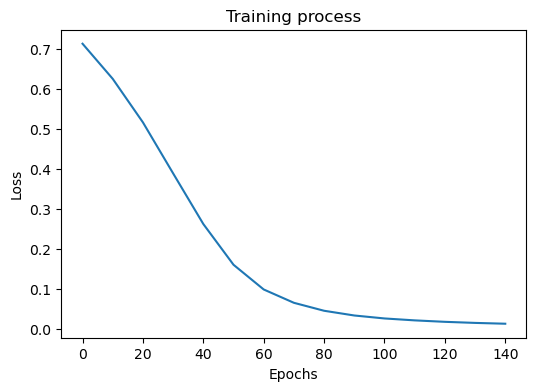

In [31]:
model.eval()

with torch.inference_mode():
    y_pred = model(x_train[0:7:2])
print(f'Got results via model: {np.int32(np.round(y_pred).reshape(4)).tolist()},\nTrue results: {y[0:7:2].tolist()}')

plt.figure(figsize=(6, 4))
plt.plot(epoch_count, train_loss)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training process')
plt.show();